In [29]:
%%time 

# autoload external python modules if they changed
%load_ext autoreload
%autoreload 2

import sys, os
pyDAmonitor_ROOT=os.getenv("pyDAmonitor_ROOT")
if pyDAmonitor_ROOT is None:
    print("!!! pyDAmonitor_ROOT is NOT set. Run `source ush/load_pyDAmonitor.sh`")
else:
    print(f"pyDAmonitor_ROOT={pyDAmonitor_ROOT}\n")
sys.path.insert(0, pyDAmonitor_ROOT)
print(f"{pyDAmonitor_ROOT}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
pyDAmonitor_ROOT=/gpfs/f6/bil-fire10-oar/world-shared/jjh/tools/pyDAmonitor

/gpfs/f6/bil-fire10-oar/world-shared/jjh/tools/pyDAmonitor
CPU times: user 0 ns, sys: 705 μs, total: 705 μs
Wall time: 579 μs


In [32]:
from netCDF4 import Dataset
import numpy as np

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

############ Constants ####################
deg2rad = np.pi / 180.0
rad2deg = 180.0 / np.pi
quarter = 0.25
one = 1.0

###########################################
grid_ratio_regional = 2.0 # =1.0, the analysis grid resolution is the same as background grid resolution; >1.0, analysis is performed on a coaser grid

# conus 12km
dlat = 0.115 # background grid resolution
dlon = 0.115 # background grid resolution

# conus 3km
#dlat = 0.027 
#dlon = 0.027 

# south 3.5km
#dlat = 0.0314 
#dlon = 0.0314  

# ncar 5km
#dlat = 0.0449
#dlon = 0.0449 

print(f"grid_ratio_regional : {np.min(grid_ratio_regional):.1f}")

grid_ratio_regional : 2.0


In [33]:
# MPAS grid
mgrid = f"{pyDAmonitor_ROOT}/data/mpasjedi/conus12km.grid.nc"
#mgrid = f"{pyDAmonitor_ROOT}/data/mpasjedi/conus3km.grid.nc"
#mgrid = f"{pyDAmonitor_ROOT}/data/mpasjedi/south3.5km.grid.nc"
#mgrid = f"/gpfs/f6/bil-fire10-oar/world-shared/gge/tmp/ea5km.grid.nc"

# Read lon/lat from *.grid.nc
nc_g = Dataset(mgrid, mode='r')
latCell_rad = nc_g.variables["latCell"][:]
lonCell_rad = nc_g.variables["lonCell"][:]
latCell_deg = latCell_rad*rad2deg
lonCell_deg = lonCell_rad*rad2deg

In [34]:
# rotate mpas grid
# create xc, yc, zc for the cell centers.
nc = np.size(latCell_rad) # number of cells

xc = np.cos(latCell_rad) * np.cos(lonCell_rad)
yc = np.cos(latCell_rad) * np.sin(lonCell_rad)
zc = np.sin(latCell_rad)

#  compute center as average x,y,z coordinates of all cells --
xcent = np.mean(xc)
ycent = np.mean(yc)
zcent = np.mean(zc)

rnorm = one / np.sqrt(xcent**2 + ycent**2 + zcent**2)
xcent *= rnorm
ycent *= rnorm
zcent *= rnorm

centlat = np.arcsin(zcent) * rad2deg
centlon = np.arctan2(ycent, xcent) * rad2deg

north_pole_lat = 90.0 - centlat
north_pole_lon = centlon + 180.0

# compute new lats, lons in the rotated lon-lat
rlon0 = centlon
rlat0 = centlat

#print(f"rlon0 : {rlon0:.6f}°, rlat0 : {rlat0:.6f}°")

x = np.cos(latCell_rad) * np.cos(lonCell_rad)
y = np.cos(latCell_rad) * np.sin(lonCell_rad)
z = np.sin(latCell_rad)

rlon0_rad = rlon0 * deg2rad
xt =  x * np.cos(rlon0_rad) + y * np.sin(rlon0_rad)
yt = -x * np.sin(rlon0_rad) + y * np.cos(rlon0_rad)
zt =  z

rlat0_rad = rlat0 * deg2rad
xtt =  xt * np.cos(rlat0_rad) + zt * np.sin(rlat0_rad)
ytt =  yt
ztt = -xt * np.sin(rlat0_rad) + zt * np.cos(rlat0_rad)

gcrlat = np.arcsin(ztt) * rad2deg
gcrlon = np.arctan2(ytt, xtt) * rad2deg

#####################################################
## compute analysis A-grid  lats, lons
#####################################################

# obtain analysis grid spacing
#print(f"gcrlat : min = {np.min(gcrlat):.6f}°, max = {np.max(gcrlat):.6f}°")
#print(f"gcrlon : min = {np.min(gcrlon):.6f}°, max = {np.max(gcrlon):.6f}°")
ny = np.ceil((np.max(gcrlat) - np.min(gcrlat)) / dlat) + 1
nx = np.ceil((np.max(gcrlon) - np.min(gcrlon)) / dlon) + 1

adlat = dlat * grid_ratio_regional
adlon = dlon * grid_ratio_regional

# rotated domain should be slightly larger than the orginal one, so add 10 grids on each boundary 
ny = int(np.ceil(ny/grid_ratio_regional)+10)
nx = int(np.ceil(nx/grid_ratio_regional)+10)

# setup analysis A-grid; find center of the domain
nlonh = nx // 2
nlath = ny // 2

if nx % 2 == 0:
    clon = adlon / 2.0
    cx = 0.5
else:
    clon = adlon
    cx = 1.0

if ny % 2 == 0:
    clat = adlat / 2.0
    cy = 0.5
else:
    clat = adlat
    cy = 1.0

# setup analysis A-grid from center of the domain
j_idx = np.arange(1, nx + 1)
i_idx = np.arange(1, ny + 1)

J, I = np.meshgrid(j_idx, i_idx)


lon_rotated = (J - nlonh) * adlon - clon
lat_rotated = (I - nlath) * adlat - clat

print(f"GSIBEC_NLAT : {ny}")
print(f"GSIBEC_NLON : {nx}")
print(f"GSIBEC_NORTH_POLE_LAT : {north_pole_lat:.6f}°")
print(f"GSIBEC_NORTH_POLE_LON : {north_pole_lon:.6f}°")
print(f"GSIBEC_LON_START : {np.min(lon_rotated):.6f}°")
print(f"GSIBEC_LON_END : {np.max(lon_rotated):.6f}°")
print(f"GSIBEC_LAT_START : {np.min(lat_rotated):.6f}°")
print(f"GSIBEC_LAT_END : {np.max(lat_rotated):.6f}°")

GSIBEC_NLAT : 153
GSIBEC_NLON : 230
GSIBEC_NORTH_POLE_LAT : 51.686294°
GSIBEC_NORTH_POLE_LON : 82.331698°
GSIBEC_LON_START : -26.335000°
GSIBEC_LON_END : 26.335000°
GSIBEC_LAT_START : -17.480000°
GSIBEC_LAT_END : 17.480000°


In [35]:
def unrotate2deg(rlon_out,rlat_out,north_pole_lon,north_pole_lat):
    rlon0 = north_pole_lon - 180.0;
    rlat0 = 90.0 - north_pole_lat;
    xtt = np.cos(rlat_out * deg2rad) * np.cos(rlon_out * deg2rad)
    ytt = np.cos(rlat_out * deg2rad) * np.sin(rlon_out * deg2rad)
    ztt = np.sin(rlat_out * deg2rad)

    xt = xtt * np.cos(rlat0 * deg2rad) - ztt * np.sin(rlat0 * deg2rad)
    yt = ytt
    zt = xtt * np.sin(rlat0 * deg2rad) + ztt * np.cos(rlat0 * deg2rad)

    x = xt * np.cos(rlon0 * deg2rad) - yt * np.sin(rlon0 * deg2rad)
    y = xt * np.sin(rlon0 * deg2rad) + yt * np.cos(rlon0 * deg2rad)
    z = zt

    rlat_in = np.asin(z) * rad2deg
    rlon_in = np.atan2(y,x) * rad2deg
    return rlat_in,rlon_in

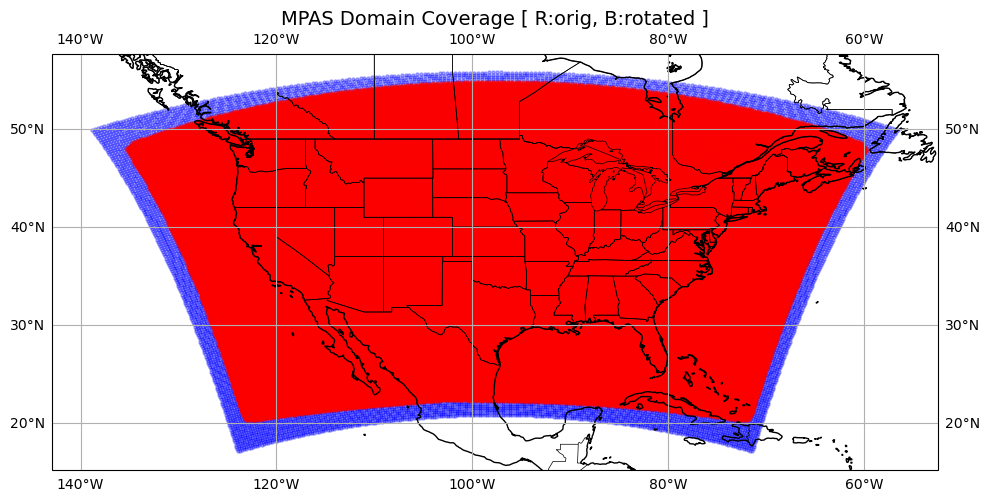

In [36]:
# --- Plot the domain coverage, before and after rotate ---
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_title("MPAS Domain Coverage [ R:orig, B:rotated ]", fontsize=14)

# Add geographic features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.5)  # U.S. state borders
ax.gridlines(draw_labels=True)

# scatter full grid points, rotated
rlat_in,rlon_in = unrotate2deg(lon_rotated,lat_rotated,north_pole_lon,north_pole_lat)
ax.scatter(rlon_in, rlat_in, s=5, color='blue', alpha=0.3, transform=ccrs.PlateCarree())

# scatter full grid points, original
ax.scatter(lonCell_deg, latCell_deg, s=5, color='red', alpha=0.3, transform=ccrs.PlateCarree())

plt.tight_layout()
plt.show()